# Phase 1: Data Loading and Initial Inspection
In this section, we import the necessary libraries and load the raw dataset to understand its initial structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the raw dataset
# Adjust the path if you are running this from a different directory
df = pd.read_csv('../data/raw/car_price_dataset.csv')

# Display the first few rows to verify
display(df.head())

,Unnamed: 0,Brand,Model,YOM,Engine (cc),Gear,Fuel Type,Millage(KM),Town,Date,Leasing,Condition,AIR CONDITION,POWER STEERING,POWER MIRROR,POWER WINDOW,Price
0,0,AUDI,A1,2016,990.0,Automatic,Petrol,99000.0,Gampaha,2025-02-05,No Leasing,USED,Available,Available,Available,Available,100.0
1,1,AUDI,A1,2017,1000.0,Automatic,Petrol,88000.0,Colombo,2025-01-14,No Leasing,USED,Available,Available,Available,Available,97.0
2,2,AUDI,A1,2018,1000.0,Automatic,Petrol,77000.0,Dehiwala-Mount-Lavinia,2025-01-23,No Leasing,USED,Available,Available,Available,Available,98.5
3,3,AUDI,A1,2017,1000.0,Automatic,Petrol,88000.0,Negombo,2024-12-21,No Leasing,USED,Available,Available,Available,Available,107.0
4,4,AUDI,A1,2017,1000.0,Automatic,Petrol,88000.0,Colombo,2024-12-21,No Leasing,USED,Available,Available,Available,Available,99.5


# Phase 2: Evidence for Feature Selection and Dimensionality Reduction
Before altering the dataset, we must justify the removal of any features. We evaluate each column for its variance (number of unique values) and completeness. Features with zero variance offer no predictive power for machine learning models.

In [6]:
# 2. Parse Dates to Numbers
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['List_Year'] = df['Date'].dt.year
    df['List_Month'] = df['Date'].dt.month
    df = df.drop(columns=['Date'])

# 3. Encode ALL categorical text into numbers
# Binary mappings
binary_mapping = {'Available': 1, 'Not-Available': 0}
for col in ['AIR CONDITION', 'POWER STEERING', 'POWER MIRROR', 'POWER WINDOW']:
    if col in df.columns:
        df[col] = df[col].map(binary_mapping)

if 'Leasing' in df.columns:
    df['Leasing'] = df['Leasing'].map({'Yes Leasing': 1, 'No Leasing': 0})
if 'Gear' in df.columns:
    df['Gear'] = df['Gear'].map({'Automatic': 1, 'Manual': 0})
if 'Condition' in df.columns:
    df['Condition'] = df['Condition'].apply(lambda x: 1 if str(x).strip().upper() == 'USED' else 0)

# Target mappings
target_enc_cols = ['Brand', 'Model', 'Fuel Type', 'Town']
for col in target_enc_cols:
    if col in df.columns:
        mapping = df.groupby(col)['Price'].mean().to_dict()
        df[col + '_encoded'] = df[col].map(mapping)
        df = df.drop(columns=[col]) # Drop original string column

print("All features successfully encoded to numerical formats.")

All features successfully encoded to numerical formats.


In [4]:
# 1. Calculate Pearson Correlation
corr_matrix = df.corr(method='pearson')

# 2. Isolate correlations with Price
price_corr = corr_matrix['Price'].drop('Price') # Drop Price vs Price (1.0)

print("--- FULL CORRELATION WITH PRICE ---")
print(price_corr.sort_values(ascending=False, na_position='first'))

# 3. Identify columns to drop based on correlation
# Condition A: NaN correlation (Zero variance / division by zero)
nan_cols = price_corr[price_corr.isna()].index.tolist()

# Condition B: Weak correlation (between -0.05 and 0.05)
# You can adjust this threshold (e.g., 0.10) based on how strict you want to be
threshold = 0.05 
weak_cols = price_corr[(price_corr.abs() < threshold)].index.tolist()

cols_to_drop = nan_cols + weak_cols

print("\n--- IDENTIFIED FOR REMOVAL ---")
print(f"NaN Correlation (Zero Variance): {nan_cols}")
print(f"Weak Correlation (Absolute value < {threshold}): {weak_cols}")

--- FULL CORRELATION WITH PRICE ---
Leasing                   NaN
AIR CONDITION             NaN
POWER STEERING            NaN
POWER MIRROR              NaN
POWER WINDOW              NaN
Model_encoded        0.947408
Brand_encoded        0.642785
YOM                  0.506669
Gear                 0.499508
Fuel Type_encoded    0.267501
Town_encoded         0.249889
Engine (cc)          0.193737
List_Year            0.023595
Condition           -0.007273
List_Month          -0.023759
Millage(KM)         -0.506669
Name: Price, dtype: float64

--- IDENTIFIED FOR REMOVAL ---
NaN Correlation (Zero Variance): ['Leasing', 'AIR CONDITION', 'POWER STEERING', 'POWER MIRROR', 'POWER WINDOW']
Weak Correlation (Absolute value < 0.05): ['Condition', 'List_Year', 'List_Month']


Original feature count: 17
Optimized feature count: 9
Features kept: ['YOM', 'Engine (cc)', 'Gear', 'Millage(KM)', 'Price', 'Brand_encoded', 'Model_encoded', 'Fuel Type_encoded', 'Town_encoded']


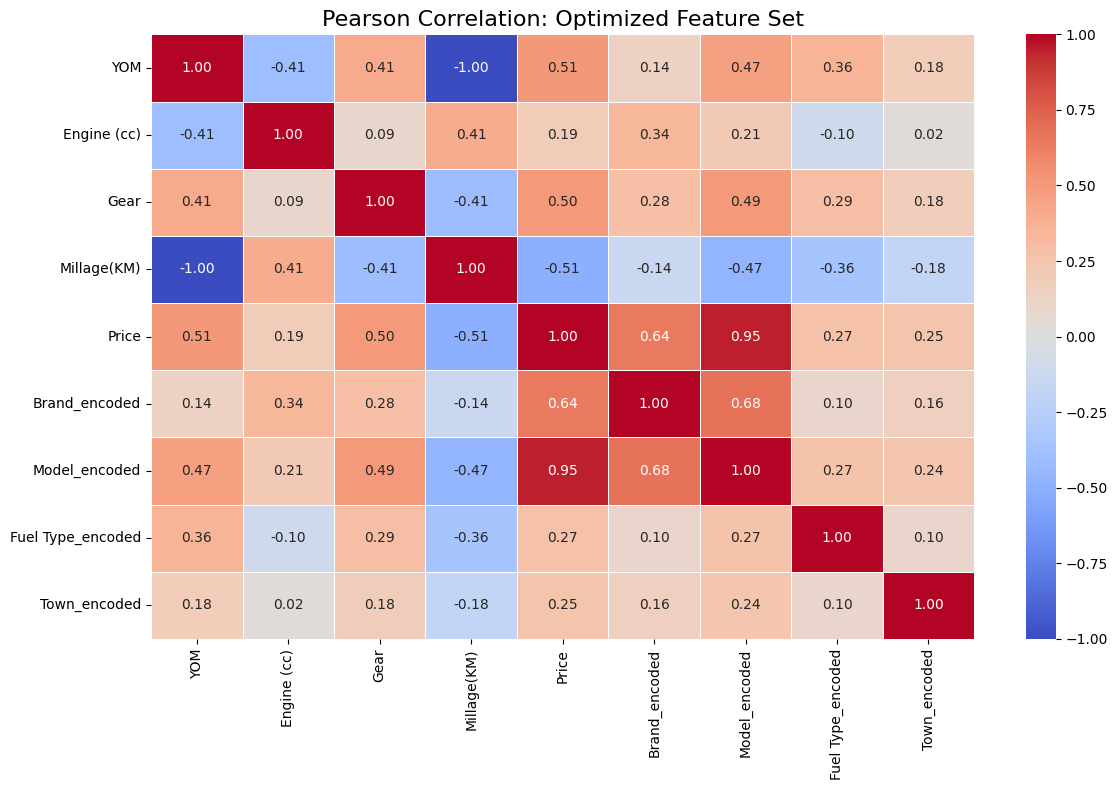

In [5]:
# Drop the identified useless/weak columns
df_optimized = df.drop(columns=cols_to_drop)

print(f"Original feature count: {df.shape[1]}")
print(f"Optimized feature count: {df_optimized.shape[1]}")
print(f"Features kept: {df_optimized.columns.tolist()}")

# Generate the final Heatmap with only the strong predictors
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_optimized.corr(method='pearson'), 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5
)
plt.title('Pearson Correlation: Optimized Feature Set', fontsize=16)
plt.tight_layout()
plt.show()